Inference means "drawing conclusion from datas", measuring a lot of data and then get some properties. The sampling is done by nature and the datas taking process. Some ideas 
What's the best estimate for a model parameter?
How confident are we on this estimation?
Are datas consistent with a model I selected or between 1 and more competing models?

We are studying properties of a population out of measured samples
Every function of the sample is a "statistics"
An "estimator" is a statistic we assign to a specifical physical meaning (e.g. estimator of a gaussian mean that estimate it). There are "interval estimator" and "point estimator".
Data are fixed.

Classical or frequentist approach: 
    the measurement errors are outcome of repeated measures. it has to do with the probability of the data; if i compute an interval confidence how much is the prob that a new data falls into
=> PROBABILITY OF THE PARAMETERS GIVEN THE DATA
Bayesian: probabilites quantify our subjective belief about experimental outcomes. we have credible regions derived from posterior probability distributions and encode "belief spread" in model parameters.
=> GIVEN THE DATA I NEED TO KNOW THE PARAMETER FROM THEM

Example: the iq of a population has mean 100 and std 15. alice do the test once and gets 160, which is the true iq of alice? Frequentist would say 160 is best possible estimator for true iq value while bayesian would conclude had lucky day and that the true value is way lower since it's unluckily to be in that interval

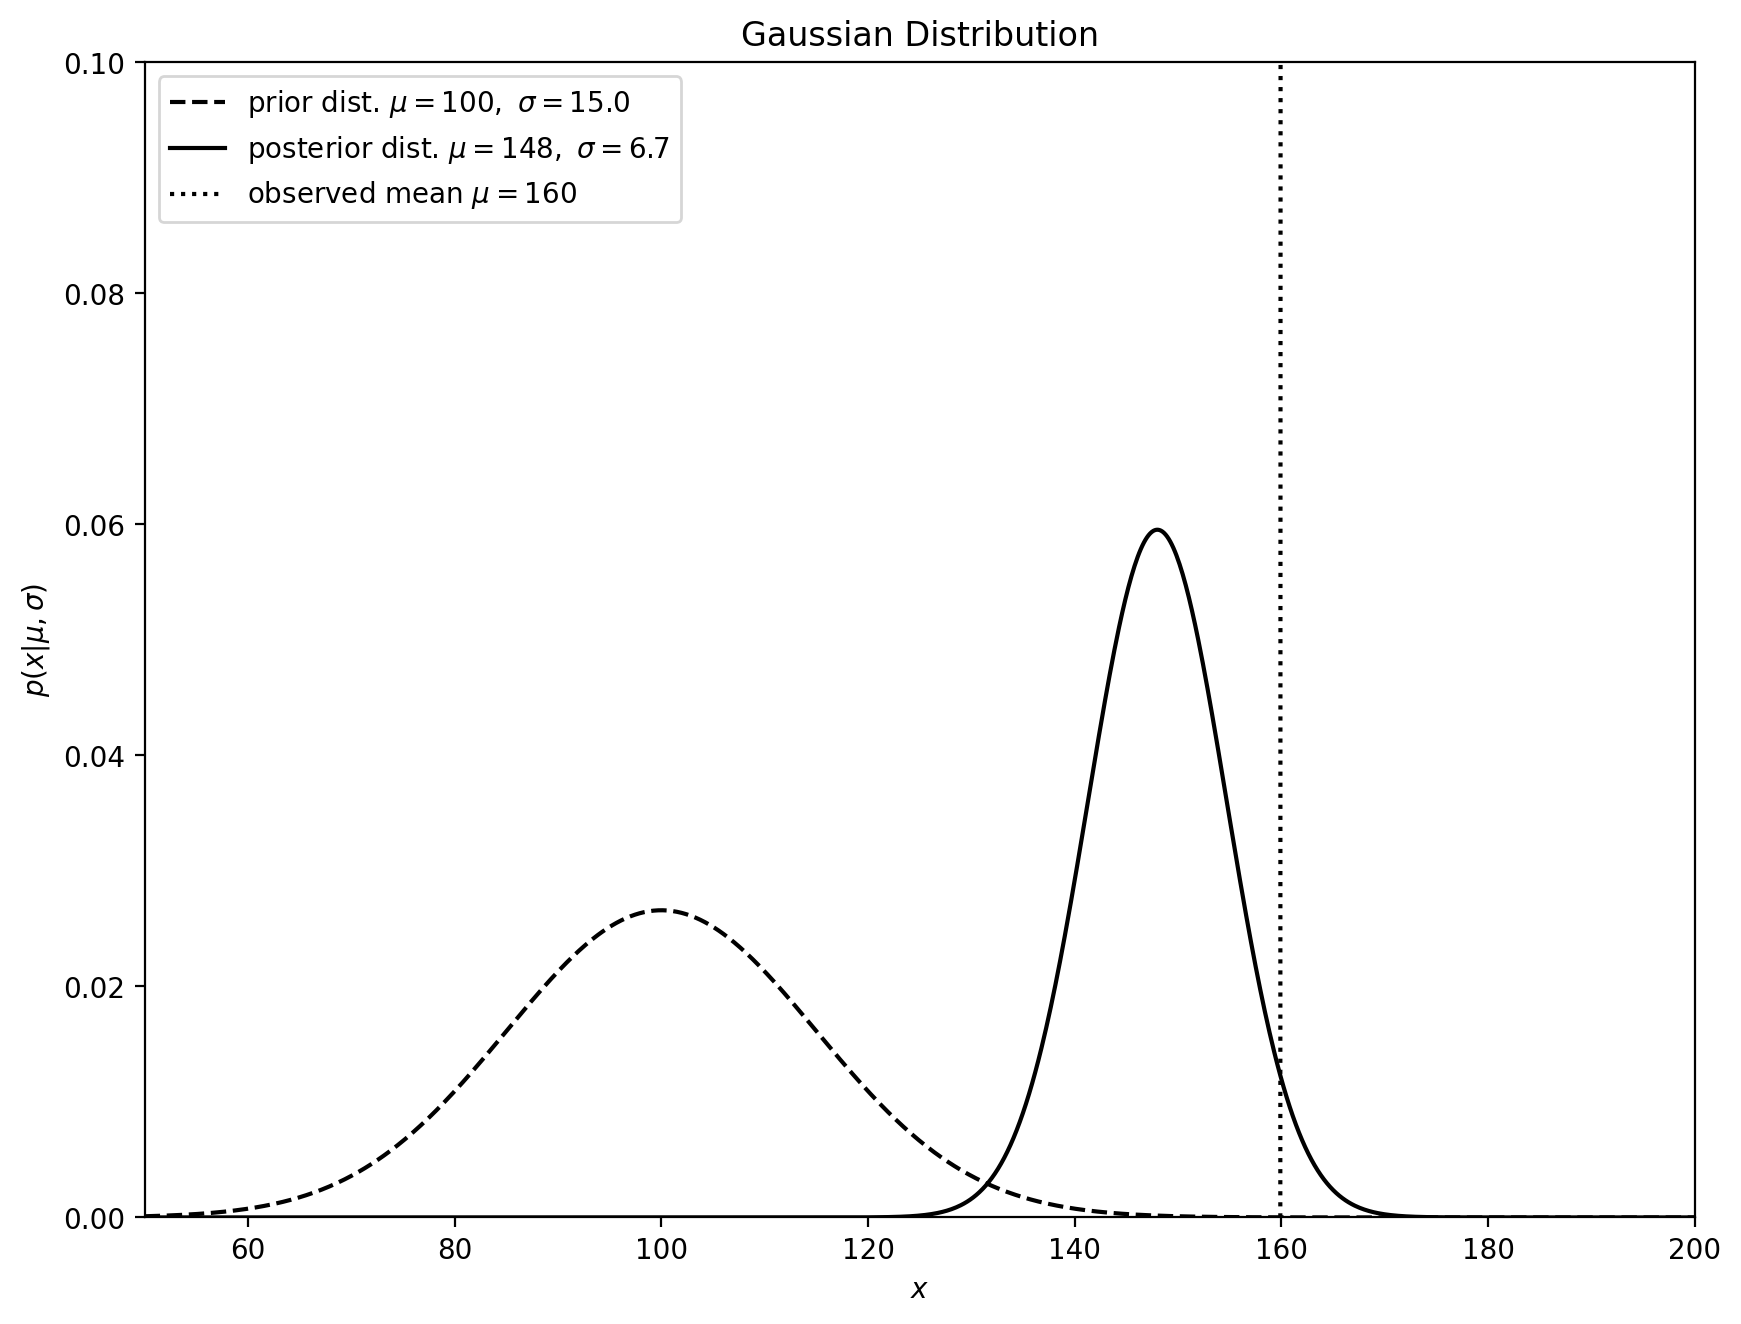

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=10, usetex=True)

#------------------------------------------------------------
# Define the distributions to be plotted
sigma_values = [15, 6.7, 1] #complete with the prior width of IQ distribution
linestyles = ['--', '-', ':']
mu_values = [100, 148, 160] #complete with the prior mean of IQ distribution
labeltext = ['prior dist.', 
             'posterior dist.', 
             'observed mean']
xplot = np.linspace(50, 200, 1000)

#------------------------------------------------------------
# plot the distributions
fig, ax = plt.subplots(figsize=(10, 7.5))

for sigma, ls, mu, lab in zip(sigma_values, 
                              linestyles, 
                              mu_values, 
                              labeltext):
    
    # create a gaussian / normal distribution
    dist = norm(mu, sigma)

    if sigma > 1:
        plt.plot(xplot, dist.pdf(xplot), 
                 ls=ls, c='black',
                 label=r'%s $\mu=%i,\ \sigma=%.1f$' % (lab, mu, sigma))
    else:
        plt.plot([159.9, 160.1], [0, 0.8], 
                 ls=ls, color='k', label=r'%s $\mu=%i$' % (lab, mu))
        
plt.xlim(50, 200)
plt.ylim(0, 0.1)
plt.xlabel('$x$')
plt.ylabel(r'$p(x|\mu,\sigma)$')
plt.title('Gaussian Distribution')
plt.legend()

Maximum Likelihood Estimator MLE
The likelihood is the probabilty of the datas, but i can think as a function of the parameters, the parameters values that maximize the likelihood.
We might ask how certain we are to this estimation, if it is peak the MLE is precise. The model selection in frequentist approach is asking which model gives me the highest likelihood.

e.g.
adopt a model where the obs. quasar does not move. we derive the expression for the likelihood being a quasar in x0, we fin x0^ for which our observations are maximally likely. we determine uncertainties on our measruemenet


the likelihood function with a gaussian
$$p(x|\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right).$$

The likelihood is a probability of the data given the parameters, i think it as a FUNCTION of the parameters. minimazing chi sq which is the least squares. Minimazing chi sq is the same of maximizing the gaussian likelihood. if it is not gaussian it's not correct.
properties of ML estimators:
they are consistent so converge to true parameters with N to inft
they are asymptotically normal, the more data i have the distribution tends to a normal gaussian with the lowest theoretical variance (cramer-rao bound) 